<a href="https://colab.research.google.com/github/aditiprasannna/DLG-lab/blob/main/Copy_of_lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
covertype = fetch_ucirepo(id=31)

# data (as pandas dataframes)
X = covertype.data.features
y = covertype.data.targets

# metadata
print(covertype.metadata)

# variable information
print(covertype.variables)


{'uci_id': 31, 'name': 'Covertype', 'repository_url': 'https://archive.ics.uci.edu/dataset/31/covertype', 'data_url': 'https://archive.ics.uci.edu/static/public/31/data.csv', 'abstract': 'Classification of pixels into 7 forest cover types based on attributes such as elevation, aspect, slope, hillshade, soil-type, and more.', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 581012, 'num_features': 54, 'feature_types': ['Categorical', 'Integer'], 'demographics': [], 'target_col': ['Cover_Type'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1998, 'last_updated': 'Sat Mar 16 2024', 'dataset_doi': '10.24432/C50K5N', 'creators': ['Jock Blackard'], 'intro_paper': None, 'additional_info': {'summary': 'Predicting forest cover type from cartographic variables only (no remotely sensed data).  The actual forest cover type for a given observation (30 x 30 meter cell) was determined from

In [ ]:
print(X.shape)
print(y.shape)

(581012, 54)
(581012, 1)


In [ ]:
print(X.head())
print(y.head())

   Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  \
0       2596      51      3                               258   
1       2590      56      2                               212   
2       2804     139      9                               268   
3       2785     155     18                               242   
4       2595      45      2                               153   

   Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
0                               0                              510   
1                              -6                              390   
2                              65                             3180   
3                             118                             3090   
4                              -1                              391   

   Hillshade_9am  Hillshade_Noon  Hillshade_3pm  \
0            221             232            148   
1            220             235            151   
2            234             238   

In [ ]:
print(np.unique(y))

[1 2 3 4 5 6 7]


In [ ]:
y = covertype.data.targets.values.ravel()


In [ ]:
print(y.shape)
print(np.unique(y))

(581012,)
[1 2 3 4 5 6 7]


In [ ]:
class_counts = np.bincount(y)[1:]
print(class_counts)

[211840 283301  35754   2747   9493  17367  20510]


In [ ]:
most_frequent = class_counts.max()
least_frequent = class_counts.min()

imbalance_ratio = most_frequent / least_frequent

print("Most frequent class:", most_frequent)
print("Least frequent class:", least_frequent)
print("Imbalance ratio:", imbalance_ratio)

Most frequent class: 283301
Least frequent class: 2747
Imbalance ratio: 103.13105205678923


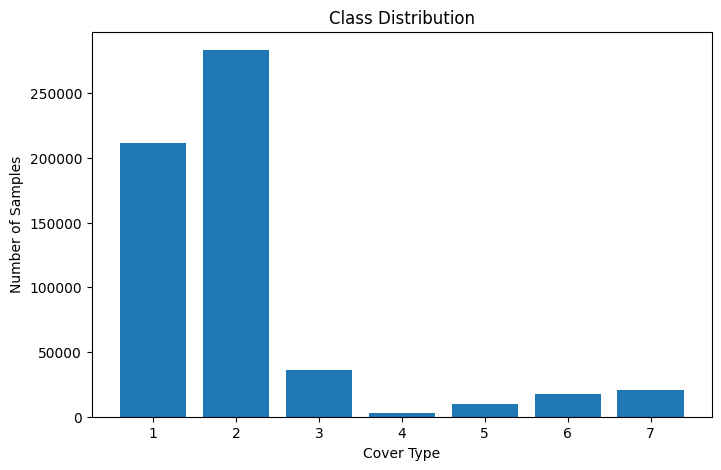

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(range(1,8), class_counts)
plt.xlabel("Cover Type")
plt.ylabel("Number of Samples")
plt.title("Class Distribution")
plt.xticks(range(1,8))
plt.show()

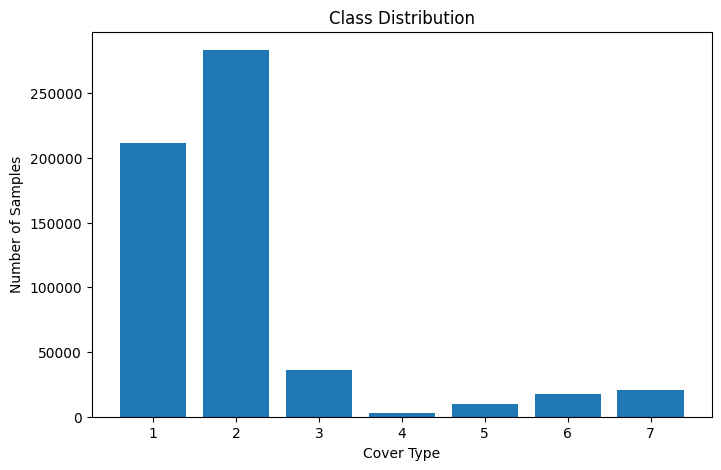

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(range(1,8), class_counts)
plt.xlabel("Cover Type")
plt.ylabel("Number of Samples")
plt.title("Class Distribution")
plt.xticks(range(1,8))
plt.show()

In [ ]:
y = y - 1

print(np.unique(y))

[0 1 2 3 4 5 6]


In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y.reshape(-1, 1))

print(y_onehot.shape)

(581012, 7)


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_onehot,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
y_temp_labels = np.argmax(y_temp, axis=1)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp_labels,
    random_state=42
)

In [ ]:
print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Testing:", X_test.shape, y_test.shape)

Training: (464809, 54) (464809, 7)
Validation: (58101, 54) (58101, 7)
Testing: (58102, 54) (58102, 7)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [ ]:
print(X_train.shape)
print(np.mean(X_train, axis=0)[:5])
print(np.std(X_train, axis=0)[:5])

(464809, 54)
[-4.14623009e-16  4.00207587e-17 -7.94682636e-17  5.49253575e-17
  3.65353756e-17]
[1. 1. 1. 1. 1.]


In [ ]:
train_labels = np.argmax(y_train, axis=1)

In [ ]:
class_counts_train = np.bincount(train_labels, minlength=7)

print(class_counts_train)

[169472 226640  28603   2198   7594  13894  16408]


In [ ]:
N = len(train_labels)
K = 7

class_weights = N / (K * class_counts_train)

print(class_weights)

[ 0.39181272  0.29298132  2.32147976 30.20986611  8.74391437  4.77913385
  4.04688479]


In [ ]:
for i, weight in enumerate(class_weights):
    print(f"Class {i}: {weight:.4f}")

Class 0: 0.3918
Class 1: 0.2930
Class 2: 2.3215
Class 3: 30.2099
Class 4: 8.7439
Class 5: 4.7791
Class 6: 4.0469


In [ ]:
input_size = 54
hidden1_size = 64
hidden2_size = 32
hidden3_size = 16
output_size = 7

In [ ]:
np.random.seed(42)

W1 = np.random.randn(input_size, hidden1_size) * np.sqrt(2 / input_size)
b1 = np.zeros((1, hidden1_size))

W2 = np.random.randn(hidden1_size, hidden2_size) * np.sqrt(2 / hidden1_size)
b2 = np.zeros((1, hidden2_size))

W3 = np.random.randn(hidden2_size, hidden3_size) * np.sqrt(2 / hidden2_size)
b3 = np.zeros((1, hidden3_size))

W4 = np.random.randn(hidden3_size, output_size) * np.sqrt(2 / hidden3_size)
b4 = np.zeros((1, output_size))

In [ ]:
print(W1.shape)
print(b1.shape)

print(W2.shape)
print(b2.shape)

print(W3.shape)
print(b3.shape)

print(W4.shape)
print(b4.shape)

(54, 64)
(1, 64)
(64, 32)
(1, 32)
(32, 16)
(1, 16)
(16, 7)
(1, 7)


In [ ]:
def relu(Z):
    return np.maximum(0, Z)

In [ ]:
def softmax(Z):
    Z = Z - np.max(Z, axis=1, keepdims=True)
    exp_Z = np.exp(Z)
    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

In [ ]:
def softmax(Z):
    Z = Z - np.max(Z, axis=1, keepdims=True)
    exp_Z = np.exp(Z)
    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

In [ ]:
def forward_propagation(X):
    Z1 = X @ W1 + b1
    A1 = relu(Z1)

    Z2 = A1 @ W2 + b2
    A2 = relu(Z2)

    Z3 = A2 @ W3 + b3
    A3 = relu(Z3)

    Z4 = A3 @ W4 + b4
    A4 = softmax(Z4)

    cache = (X, Z1, A1, Z2, A2, Z3, A3, Z4, A4)

    return A4, cache

In [ ]:
X_sample = X_train[:5]

predictions, cache = forward_propagation(X_sample)

print(predictions)
print(predictions.shape)

[[1.42394448e-01 9.73233487e-02 9.64823103e-02 1.33575213e-01
  9.27991926e-02 1.30053928e-01 3.07371559e-01]
 [1.64085254e-01 1.25844619e-01 2.05537153e-01 1.09621837e-01
  1.09694787e-01 1.52321281e-01 1.32895070e-01]
 [2.73580010e-02 1.98028380e-03 1.69852012e-03 5.85377865e-02
  4.60181852e-04 2.24895756e-03 9.07716269e-01]
 [1.25583571e-01 1.55310747e-01 1.40146564e-01 1.38608486e-01
  1.12742432e-01 1.51057480e-01 1.76550719e-01]
 [1.01835422e-01 1.73128731e-01 1.98398023e-01 2.06385445e-01
  5.46590532e-02 1.14433524e-01 1.51159801e-01]]
(5, 7)


In [ ]:
print(np.sum(predictions, axis=1))

[1. 1. 1. 1. 1.]


In [ ]:
def compute_loss(y_true, y_pred, class_weights):
    y_pred = np.clip(y_pred, 1e-12, 1 - 1e-12)
    weights = np.sum(y_true * class_weights, axis=1)
    loss = -np.mean(weights * np.sum(y_true * np.log(y_pred), axis=1))
    return loss

In [ ]:
weights = np.sum(y_train * class_weights, axis=1)

In [ ]:
loss = compute_loss(y_train[:5], predictions, class_weights)
print("Loss:", loss)

Loss: 5.582000557646859


In [ ]:
def relu_derivative(Z):
    return (Z > 0).astype(float)

In [ ]:
def backward_propagation(y_true, y_pred, cache, class_weights):
    X, Z1, A1, Z2, A2, Z3, A3, Z4, A4 = cache

    m = X.shape[0]

    sample_weights = np.sum(y_true * class_weights, axis=1, keepdims=True)

    dZ4 = (A4 - y_true) * sample_weights / m
    dW4 = A3.T @ dZ4
    db4 = np.sum(dZ4, axis=0, keepdims=True)

    dA3 = dZ4 @ W4.T
    dZ3 = dA3 * relu_derivative(Z3)
    dW3 = A2.T @ dZ3
    db3 = np.sum(dZ3, axis=0, keepdims=True)

    dA2 = dZ3 @ W3.T
    dZ2 = dA2 * relu_derivative(Z2)
    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    return dW1, db1, dW2, db2, dW3, db3, dW4, db4

In [ ]:
gradients = backward_propagation(
    y_train[:5],
    predictions,
    cache,
    class_weights
)

for gradient in gradients:
    print(gradient.shape)

(54, 64)
(1, 64)
(64, 32)
(1, 32)
(32, 16)
(1, 16)
(16, 7)
(1, 7)


In [ ]:
batch_size = 128
learning_rate = 0.01
epochs = 100
patience = 15

In [ ]:
def train_model(X_train, y_train, X_val, y_val, class_weights, batch_size, learning_rate, epochs, patience):

    global W1, b1, W2, b2, W3, b3, W4, b4

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    best_val_loss = np.inf
    best_parameters = None
    patience_counter = 0

    n_samples = X_train.shape[0]

    for epoch in range(epochs):

        indices = np.random.permutation(n_samples)

        X_train_shuffled = X_train[indices]
        y_train_shuffled = y_train[indices]

        for start in range(0, n_samples, batch_size):

            end = start + batch_size

            X_batch = X_train_shuffled[start:end]
            y_batch = y_train_shuffled[start:end]

            y_pred, cache = forward_propagation(X_batch)

            gradients = backward_propagation(
                y_batch,
                y_pred,
                cache,
                class_weights
            )

            dW1, db1, dW2, db2, dW3, db3, dW4, db4 = gradients

            W1 -= learning_rate * dW1
            b1 -= learning_rate * db1

            W2 -= learning_rate * dW2
            b2 -= learning_rate * db2

            W3 -= learning_rate * dW3
            b3 -= learning_rate * db3

            W4 -= learning_rate * dW4
            b4 -= learning_rate * db4

        train_pred, _ = forward_propagation(X_train)
        val_pred, _ = forward_propagation(X_val)

        train_loss = compute_loss(
            y_train,
            train_pred,
            class_weights
        )

        val_loss = compute_loss(
            y_val,
            val_pred,
            class_weights
        )

        train_accuracy = np.mean(
            np.argmax(train_pred, axis=1) == np.argmax(y_train, axis=1)
        )

        val_accuracy = np.mean(
            np.argmax(val_pred, axis=1) == np.argmax(y_val, axis=1)
        )

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)

        print(
            f"Epoch {epoch + 1}/{epochs} "
            f"- Train Loss: {train_loss:.4f} "
            f"- Val Loss: {val_loss:.4f} "
            f"- Train Acc: {train_accuracy:.4f} "
            f"- Val Acc: {val_accuracy:.4f}"
        )

        if val_loss < best_val_loss:

            best_val_loss = val_loss

            best_parameters = (
                W1.copy(),
                b1.copy(),
                W2.copy(),
                b2.copy(),
                W3.copy(),
                b3.copy(),
                W4.copy(),
                b4.copy()
            )

            patience_counter = 0

        else:

            patience_counter += 1

            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    W1, b1, W2, b2, W3, b3, W4, b4 = best_parameters

    history = {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "train_accuracy": train_accuracies,
        "val_accuracy": val_accuracies
    }

    return history

In [ ]:
history = train_model(
    X_train,
    y_train,
    X_val,
    y_val,
    class_weights,
    batch_size,
    learning_rate,
    epochs,
    patience
)

Epoch 1/100 - Train Loss: 0.6900 - Val Loss: 0.7041 - Train Acc: 0.5896 - Val Acc: 0.5897
Epoch 2/100 - Train Loss: 0.6319 - Val Loss: 0.6388 - Train Acc: 0.6174 - Val Acc: 0.6167
Epoch 3/100 - Train Loss: 0.5771 - Val Loss: 0.5888 - Train Acc: 0.6476 - Val Acc: 0.6473
Epoch 4/100 - Train Loss: 0.5602 - Val Loss: 0.5766 - Train Acc: 0.6840 - Val Acc: 0.6859
Epoch 5/100 - Train Loss: 0.5388 - Val Loss: 0.5516 - Train Acc: 0.6751 - Val Acc: 0.6759
Epoch 6/100 - Train Loss: 0.5109 - Val Loss: 0.5191 - Train Acc: 0.6814 - Val Acc: 0.6834
Epoch 7/100 - Train Loss: 0.5210 - Val Loss: 0.5357 - Train Acc: 0.7005 - Val Acc: 0.7023
Epoch 8/100 - Train Loss: 0.4897 - Val Loss: 0.4995 - Train Acc: 0.6698 - Val Acc: 0.6701
Epoch 9/100 - Train Loss: 0.4800 - Val Loss: 0.4872 - Train Acc: 0.7132 - Val Acc: 0.7148
Epoch 10/100 - Train Loss: 0.4697 - Val Loss: 0.4797 - Train Acc: 0.7105 - Val Acc: 0.7125
Epoch 11/100 - Train Loss: 0.4549 - Val Loss: 0.4629 - Train Acc: 0.7086 - Val Acc: 0.7101
Epoch 12

In [ ]:
test_probabilities, _ = forward_propagation(X_test)

test_predictions = np.argmax(test_probabilities, axis=1)
test_true = np.argmax(y_test, axis=1)

print(test_probabilities.shape)
print(test_predictions.shape)
print(test_true.shape)

(58102, 7)
(58102,)
(58102,)


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(test_true, test_predictions)

print("Test Accuracy:", accuracy)
print("Test Accuracy (%):", accuracy * 100)

Test Accuracy: 0.8028639289525318
Test Accuracy (%): 80.28639289525317


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [ ]:
precision = precision_score(
    test_true,
    test_predictions,
    average=None,
    zero_division=0
)

recall = recall_score(
    test_true,
    test_predictions,
    average=None,
    zero_division=0
)

f1 = f1_score(
    test_true,
    test_predictions,
    average=None,
    zero_division=0
)

macro_precision = precision_score(
    test_true,
    test_predictions,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    test_true,
    test_predictions,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    test_true,
    test_predictions,
    average="macro",
    zero_division=0
)

In [ ]:
for i in range(7):
    print(
        f"Class {i}: "
        f"Precision = {precision[i]:.4f}, "
        f"Recall = {recall[i]:.4f}, "
        f"F1 = {f1[i]:.4f}"
    )

print()
print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro Recall: {macro_recall:.4f}")
print(f"Macro F1: {macro_f1:.4f}")

Class 0: Precision = 0.8013, Recall = 0.8143, F1 = 0.8077
Class 1: Precision = 0.8851, Recall = 0.7667, F1 = 0.8216
Class 2: Precision = 0.8091, Recall = 0.8202, F1 = 0.8146
Class 3: Precision = 0.5295, Recall = 0.9818, F1 = 0.6880
Class 4: Precision = 0.4139, Recall = 0.9547, F1 = 0.5774
Class 5: Precision = 0.6110, Recall = 0.8854, F1 = 0.7231
Class 6: Precision = 0.6360, Recall = 0.9898, F1 = 0.7744

Macro Precision: 0.6694
Macro Recall: 0.8876
Macro F1: 0.7438


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        test_true,
        test_predictions,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0     0.8013    0.8143    0.8077     21184
           1     0.8851    0.7667    0.8216     28331
           2     0.8091    0.8202    0.8146      3576
           3     0.5295    0.9818    0.6880       274
           4     0.4139    0.9547    0.5774       949
           5     0.6110    0.8854    0.7231      1737
           6     0.6360    0.9898    0.7744      2051

    accuracy                         0.8029     58102
   macro avg     0.6694    0.8876    0.7438     58102
weighted avg     0.8235    0.8029    0.8069     58102



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_true, test_predictions)

print(cm)
print(cm.shape)

[[17251  2750    15     0   158    23   987]
 [ 4258 21721   530     5  1089   553   175]
 [    0    35  2933   188    29   391     0]
 [    0     0     0   269     0     5     0]
 [    2    23    11     0   906     7     0]
 [    0    10   136    46     7  1538     0]
 [   19     2     0     0     0     0  2030]]
(7, 7)


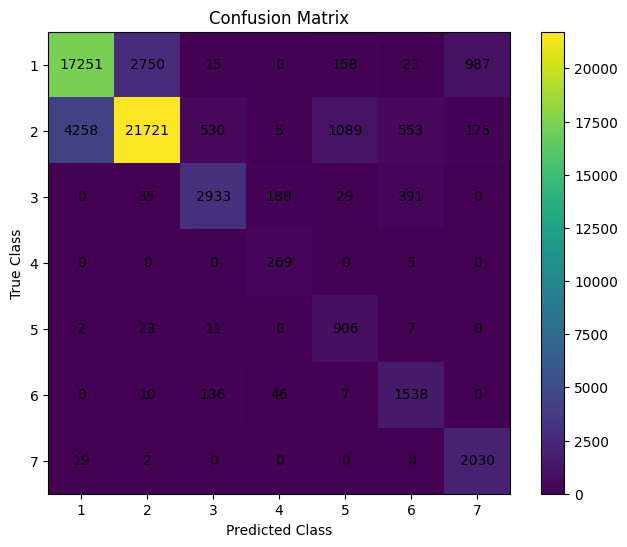

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.imshow(cm)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix")

plt.xticks(range(7), range(1,8))
plt.yticks(range(7), range(1,8))

for i in range(7):
    for j in range(7):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

In [ ]:
history


{'train_loss': [np.float64(0.6899698614659571),
  np.float64(0.631853720108623),
  np.float64(0.577134060638729),
  np.float64(0.560249726837633),
  np.float64(0.5388120852667742),
  np.float64(0.5108898119945774),
  np.float64(0.5210000871282524),
  np.float64(0.489688627883204),
  np.float64(0.48004693191184106),
  np.float64(0.469747997565458),
  np.float64(0.4549499956200938),
  np.float64(0.4971157309295167),
  np.float64(0.4373999589267855),
  np.float64(0.44109143219868874),
  np.float64(0.430994385366114),
  np.float64(0.42045643347754535),
  np.float64(0.41784854177678693),
  np.float64(0.40824963028630623),
  np.float64(0.40399368567962995),
  np.float64(0.40263608157195596),
  np.float64(0.398062805602829),
  np.float64(0.3854780560751129),
  np.float64(0.39035694774407786),
  np.float64(0.44015816383977285),
  np.float64(0.3885777433343386),
  np.float64(0.46422547584046725),
  np.float64(0.3783861264270653),
  np.float64(0.378185762973552),
  np.float64(0.36548382900594384

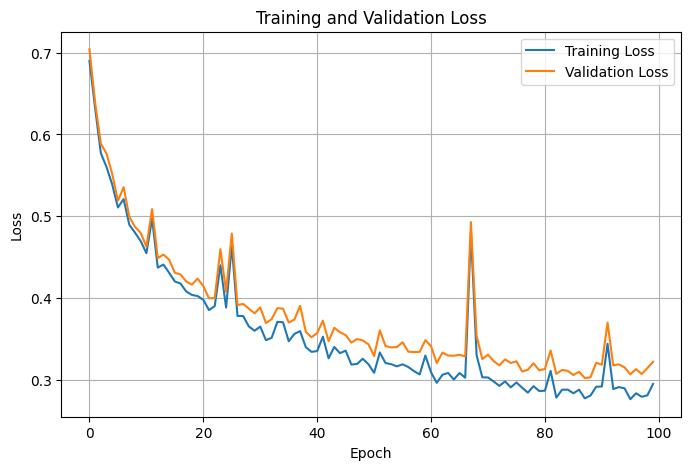

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history["train_loss"], label="Training Loss")
plt.plot(history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid()
plt.show()

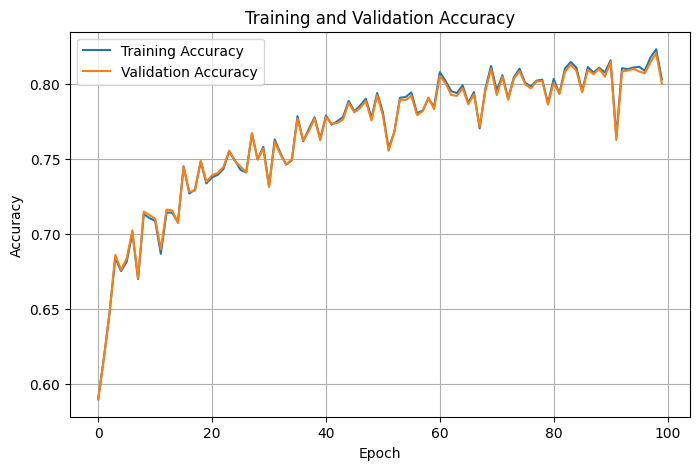

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history["train_accuracy"], label="Training Accuracy")
plt.plot(history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.grid()
plt.show()

In [ ]:
f1

array([0.80774453, 0.82164473, 0.81460908, 0.68797954, 0.57743786,
       0.72308416, 0.77436582])

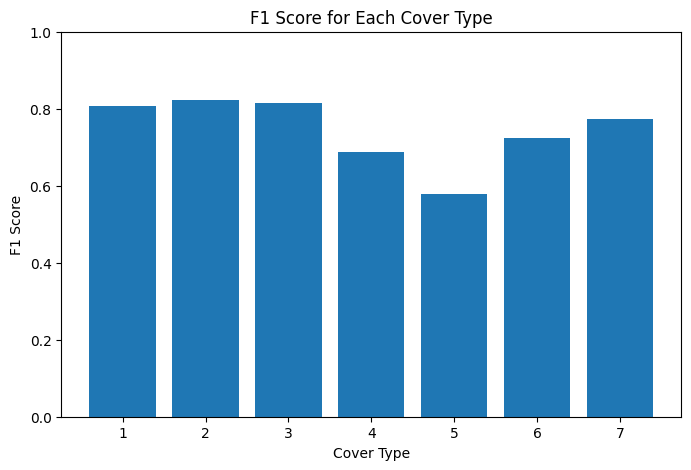

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(range(1, 8), f1)

plt.xlabel("Cover Type")
plt.ylabel("F1 Score")
plt.title("F1 Score for Each Cover Type")

plt.xticks(range(1, 8))

plt.ylim(0, 1)

plt.show()

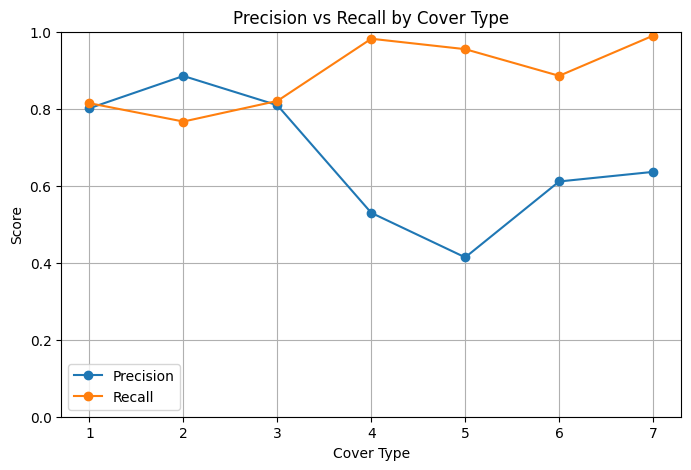

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, 8), precision, marker="o", label="Precision")
plt.plot(range(1, 8), recall, marker="o", label="Recall")

plt.xlabel("Cover Type")
plt.ylabel("Score")
plt.title("Precision vs Recall by Cover Type")

plt.xticks(range(1, 8))
plt.ylim(0, 1)

plt.legend()
plt.grid()

plt.show()

In [ ]:
true_counts = np.bincount(test_true, minlength=7)
predicted_counts = np.bincount(test_predictions, minlength=7)

print("True:", true_counts)
print("Predicted:", predicted_counts)

True: [21184 28331  3576   274   949  1737  2051]
Predicted: [21530 24541  3625   508  2189  2517  3192]


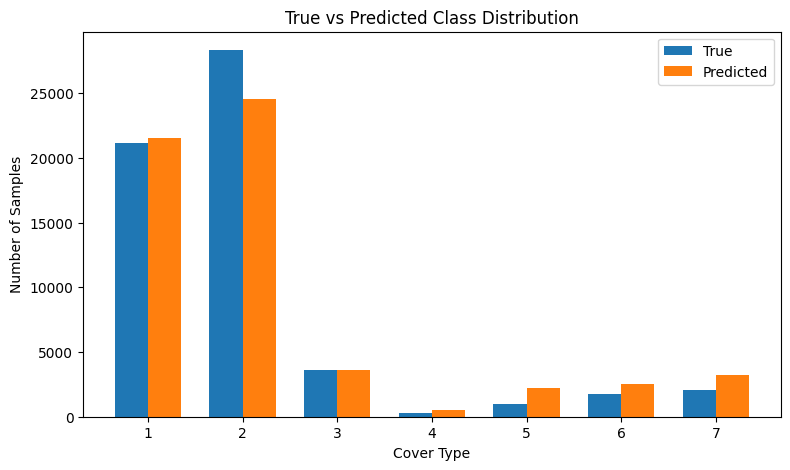

In [ ]:
x = np.arange(7)
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(x - width/2, true_counts, width, label="True")
plt.bar(x + width/2, predicted_counts, width, label="Predicted")

plt.xlabel("Cover Type")
plt.ylabel("Number of Samples")
plt.title("True vs Predicted Class Distribution")

plt.xticks(x, range(1, 8))

plt.legend()
plt.show()

In [ ]:
print("MODEL PERFORMANCE")
print("-----------------")

print(f"Accuracy        : {accuracy:.4f}")
print(f"Macro Precision : {macro_precision:.4f}")
print(f"Macro Recall    : {macro_recall:.4f}")
print(f"Macro F1        : {macro_f1:.4f}")

print("\nPer-Class F1 Scores")

for i in range(7):
    print(f"Class {i + 1}: {f1[i]:.4f}")

MODEL PERFORMANCE
-----------------
Accuracy        : 0.8029
Macro Precision : 0.6694
Macro Recall    : 0.8876
Macro F1        : 0.7438

Per-Class F1 Scores
Class 1: 0.8077
Class 2: 0.8216
Class 3: 0.8146
Class 4: 0.6880
Class 5: 0.5774
Class 6: 0.7231
Class 7: 0.7744
